# EDA — DS_FILOSOFI_CC_data.csv
Urban Data Explorer · INSEE / Filosofi 2021

> **Filosofi** (Fichier localisé social et fiscal) : indicateurs de revenus, pauvreté et inégalités  
> à l'échelle communale et supra-communale.  
> Dataset SDMX au format long : 1 ligne = 1 mesure × 1 zone géographique × 1 année.


## 0. Imports & configuration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


## 1. Chargement

In [5]:
FILE = 'DS_FILOSOFI_CC_data.csv'

FILE = '../brute/Nouveau dossier/base-cc-filosofi-2021-geo2025_csv (2)/DS_FILOSOFI_CC_data.csv'


df = pd.read_csv(FILE, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)

print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(5)


Shape : (833400, 9)
Colonnes : ['GEO', 'GEO_OBJECT', 'FILOSOFI_MEASURE', 'UNIT_MEASURE', 'UNIT_MULT', 'CONF_STATUS', 'OBS_STATUS', 'TIME_PERIOD', 'OBS_VALUE']


,GEO,GEO_OBJECT,FILOSOFI_MEASURE,UNIT_MEASURE,UNIT_MULT,CONF_STATUS,OBS_STATUS,TIME_PERIOD,OBS_VALUE
0,14226,COM,S_SOC_BEN_DI,PT,0,C,A,2021,NaN
1,14215,COM,S_SOC_BEN_DI,PT,0,F,A,2021,4.9
2,14305,COM,S_SOC_BEN_DI_MIN_SOC,PT,0,C,A,2021,NaN
3,14240,COM,S_SOC_BEN_DI_FAM_BEN,PT,0,C,A,2021,NaN
4,14240,COM,NUM_PER,PS,0,F,A,2021,478.0


## 2. Infos générales

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833400 entries, 0 to 833399
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   GEO               833400 non-null  object 
 1   GEO_OBJECT        833400 non-null  object 
 2   FILOSOFI_MEASURE  833400 non-null  object 
 3   UNIT_MEASURE      833400 non-null  object 
 4   UNIT_MULT         833400 non-null  int64  
 5   CONF_STATUS       833400 non-null  object 
 6   OBS_STATUS        833400 non-null  object 
 7   TIME_PERIOD       833400 non-null  int64  
 8   OBS_VALUE         345375 non-null  float64
dtypes: float64(1), int64(2), object(6)
memory usage: 57.2+ MB


In [7]:
print(f"Années couvertes   : {sorted(df['TIME_PERIOD'].unique())}")
print(f"Zones géographiques uniques (GEO) : {df['GEO'].nunique():,}")
print()
print('Distribution des types de zone (GEO_OBJECT) :')
print(df['GEO_OBJECT'].value_counts())
print()
print('Indicateurs disponibles (FILOSOFI_MEASURE) :')
print(df['FILOSOFI_MEASURE'].value_counts())


Années couvertes   : [np.int64(2021)]
Zones géographiques uniques (GEO) : 37,812

Distribution des types de zone (GEO_OBJECT) :
GEO_OBJECT
COM        696080
UU2020      48800
BV2022      33900
EPCI        24800
AAV2020     13840
ARR          6560
ZE2020       5940
DEP          1960
ARM           900
OTHER         300
REG           300
FRANCE         20
Name: count, dtype: int64

Indicateurs disponibles (FILOSOFI_MEASURE) :
FILOSOFI_MEASURE
S_SOC_BEN_DI            41670
S_SOC_BEN_DI_MIN_SOC    41670
S_SOC_BEN_DI_FAM_BEN    41670
NUM_PER                 41670
S_EI_DI                 41670
S_DIR_TAX_DI            41670
S_EI_DI_UNE             41670
S_EI_DI_N_SAL           41670
NUM_CU                  41670
PR_MD60                 41670
IR_D9_D1_SL             41670
S_INC_ASS_DI            41670
MED_SL                  41670
D1_SL                   41670
S_SOC_BEN_DI_HOU_BEN    41670
NUM_HH                  41670
S_HH_TAX                41670
D9_SL                   41670
S_EI_DI_SAL     

### Dictionnaire des indicateurs clés

| Code | Libellé | Unité |
|---|---|---|
| `MED_SL` | Revenu médian par UC | EUR/an |
| `D1_SL` | 1er décile de revenu | EUR/an |
| `D9_SL` | 9e décile de revenu | EUR/an |
| `IR_D9_D1_SL` | Rapport interdécile D9/D1 (inégalités) | ratio |
| `PR_MD60` | Taux de pauvreté (< 60 % médiane) | % |
| `NUM_HH` | Nombre de ménages | nb |
| `NUM_PER` | Nombre de personnes | nb |
| `NUM_CU` | Nombre d'unités de consommation | nb |
| `S_EI_DI` | Part salaires dans revenu disponible | % |
| `S_RET_PEN_DI` | Part retraites/pensions | % |
| `S_SOC_BEN_DI` | Part prestations sociales | % |
| `S_DIR_TAX_DI` | Part impôts directs (négatif) | % |
| `S_HH_TAX` | % ménages imposables | % |


## 3. Valeurs manquantes

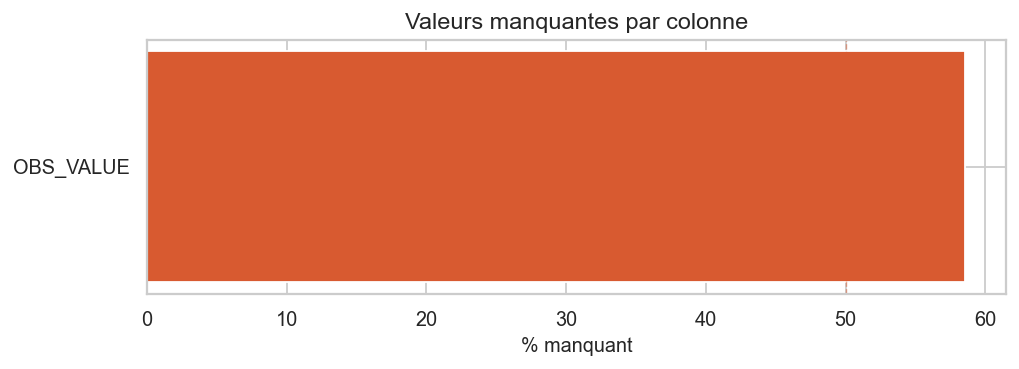

,% manquant
OBS_VALUE,58.6%


In [8]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.5)))
colors = ['#D85A30' if v > 50 else '#BA7517' if v > 20 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne')
ax.axvline(50, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

display(missing.rename('% manquant').to_frame().style.format('{:.1f}%'))


In [9]:
# Explication structurelle : CONF_STATUS = C → valeur confidentielle → NaN
print('CONF_STATUS :')
print(df['CONF_STATUS'].value_counts())
print()
print('OBS_VALUE non nulle quand CONF_STATUS = F (diffusable) :')
print(df.groupby('CONF_STATUS')['OBS_VALUE'].apply(lambda x: f"{x.notna().sum():,} valides / {len(x):,} total"))
print()
print('=> Les NaN sont structurels : données confidentielles (< seuil de diffusion INSEE)')


CONF_STATUS :
CONF_STATUS
C    487685
F    345715
Name: count, dtype: int64

OBS_VALUE non nulle quand CONF_STATUS = F (diffusable) :
CONF_STATUS
C          0 valides / 487,685 total
F    345,375 valides / 345,715 total
Name: OBS_VALUE, dtype: object

=> Les NaN sont structurels : données confidentielles (< seuil de diffusion INSEE)


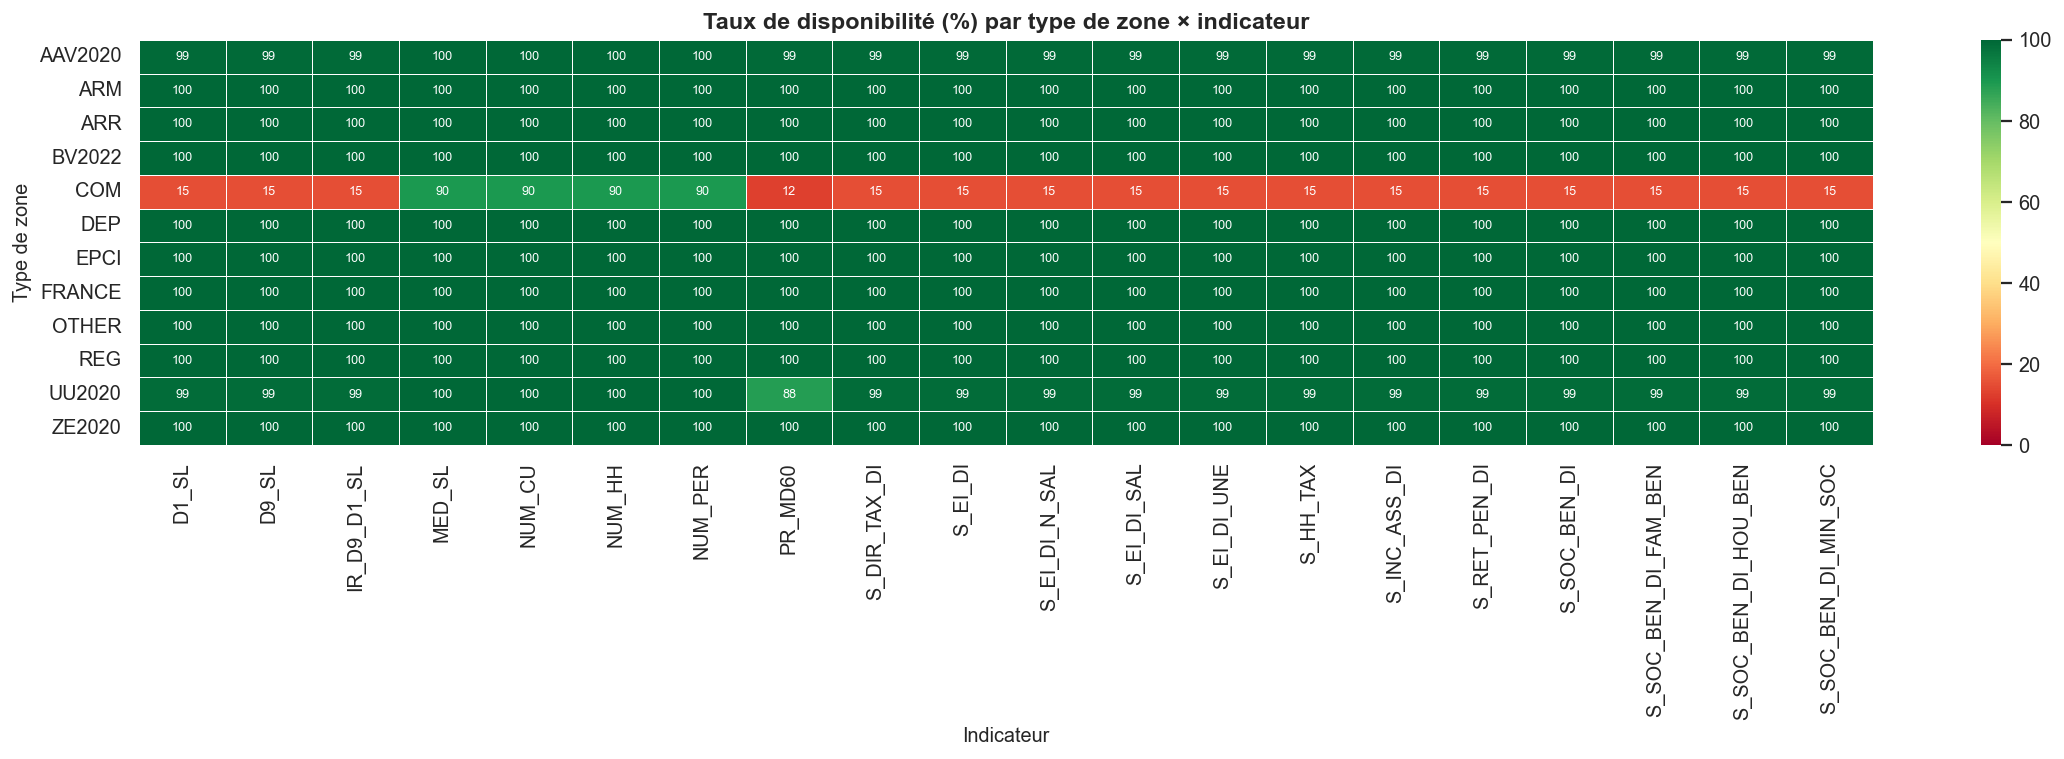

In [10]:
# Taux de disponibilité par indicateur et type de zone
pivot_miss = (df.groupby(['GEO_OBJECT','FILOSOFI_MEASURE'])['OBS_VALUE']
                .apply(lambda x: x.notna().mean() * 100)
                .unstack('FILOSOFI_MEASURE')
                .round(1))

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot_miss, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.3, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Taux de disponibilité (%) par type de zone × indicateur', fontweight='bold')
ax.set_xlabel('Indicateur')
ax.set_ylabel('Type de zone')
plt.tight_layout()
plt.show()


## 4. Doublons

In [11]:
n_dup = df.duplicated().sum()
print(f'Doublons stricts : {n_dup}')

# Clé naturelle : GEO × GEO_OBJECT × FILOSOFI_MEASURE × TIME_PERIOD
n_dup_key = df.duplicated(subset=['GEO','GEO_OBJECT','FILOSOFI_MEASURE','TIME_PERIOD']).sum()
print(f'Doublons sur clé naturelle (GEO × MEASURE × YEAR) : {n_dup_key}')
print(f'=> Chaque ligne est bien unique sur sa clé métier.')


Doublons stricts : 0
Doublons sur clé naturelle (GEO × MEASURE × YEAR) : 0
=> Chaque ligne est bien unique sur sa clé métier.


## 5. Structure du format long (SDMX)

In [12]:
# Le dataset est en format long : 1 ligne = 1 observation
# Pour analyser, on pivote vers le format wide sur les communes

df_com = df[(df['GEO_OBJECT'] == 'COM') & (df['CONF_STATUS'] == 'F')].copy()
print(f'Communes diffusables : {df_com["GEO"].nunique():,} communes, {len(df_com):,} lignes')

df_wide = df_com.pivot_table(
    index='GEO', columns='FILOSOFI_MEASURE', values='OBS_VALUE', aggfunc='first'
)
print(f'\nFormat wide : {df_wide.shape[0]:,} communes × {df_wide.shape[1]} indicateurs')
df_wide.head(3)


Communes diffusables : 31,228 communes, 209,056 lignes

Format wide : 31,212 communes × 20 indicateurs


FILOSOFI_MEASURE,D1_SL,D9_SL,IR_D9_D1_SL,MED_SL,NUM_CU,NUM_HH,NUM_PER,PR_MD60,S_DIR_TAX_DI,S_EI_DI,S_EI_DI_N_SAL,S_EI_DI_SAL,S_EI_DI_UNE,S_HH_TAX,S_INC_ASS_DI,S_RET_PEN_DI,S_SOC_BEN_DI,S_SOC_BEN_DI_FAM_BEN,S_SOC_BEN_DI_HOU_BEN,S_SOC_BEN_DI_MIN_SOC
GEO,,,,,,,,,,,,,,,,,,,,
01001,NaN,NaN,NaN,25820.0,590.8,346.0,895.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01002,NaN,NaN,NaN,24480.0,181.0,115.0,266.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01004,11890.0,36450.0,3.1,21660.0,10398.2,6855.0,15092.0,17.0,-14.8,72.3,3.4,65.7,3.2,50.0,10.2,25.3,7.0,2.6,1.4,3.0


In [13]:
print('Taux de remplissage par indicateur (communes) :')
fill = (df_wide.notna().sum() / len(df_wide) * 100).sort_values(ascending=False)
display(fill.rename('% renseigné').to_frame().style.format('{:.1f}%'))


Taux de remplissage par indicateur (communes) :


,% renseigné
FILOSOFI_MEASURE,
MED_SL,100.0%
NUM_PER,100.0%
NUM_HH,100.0%
NUM_CU,100.0%
S_HH_TAX,17.0%
IR_D9_D1_SL,17.0%
D1_SL,17.0%
D9_SL,17.0%
S_EI_DI_N_SAL,17.0%


## 6. Revenu médian par UC (MED_SL)

In [14]:
med = df_wide['MED_SL'].dropna()

print(f'Communes avec MED_SL : {len(med):,}')
print(f'Médiane nationale    : {med.median():,.0f} €/an')
print(f'Moyenne              : {med.mean():,.0f} €/an')
print(f'Min                  : {med.min():,.0f} € ({df_wide["MED_SL"].idxmin()})')
print(f'Max                  : {med.max():,.0f} € ({df_wide["MED_SL"].idxmax()})')


Communes avec MED_SL : 31,212
Médiane nationale    : 22,810 €/an
Moyenne              : 23,239 €/an
Min                  : 12,260 € (11346)
Max                  : 55,340 € (01180)


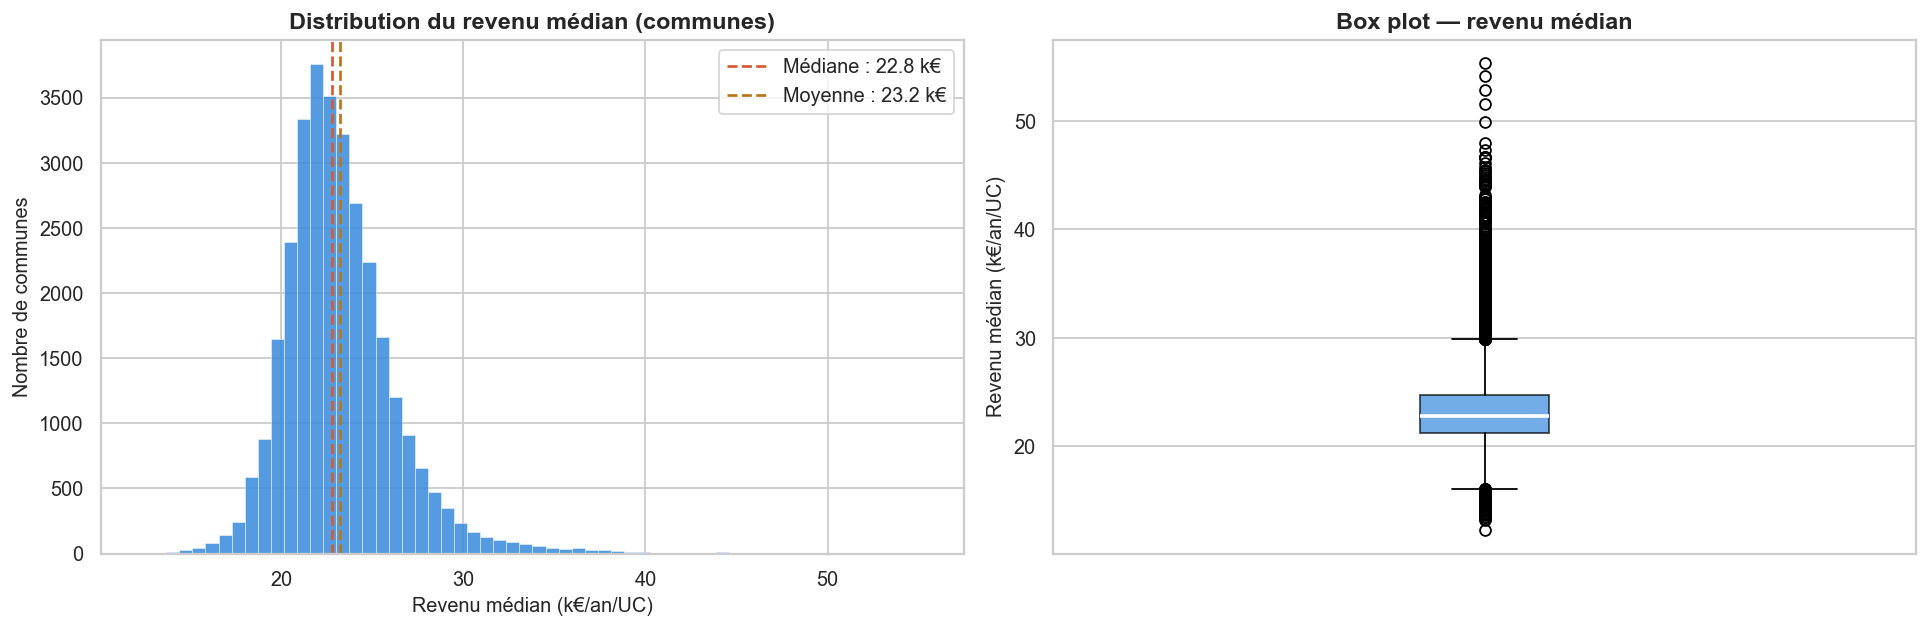

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme
axes[0].hist(med / 1000, bins=60, color='#378ADD', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].axvline(med.median() / 1000, color='#D85A30', linestyle='--', linewidth=1.5, label=f'Médiane : {med.median()/1000:.1f} k€')
axes[0].axvline(med.mean() / 1000, color='#BA7517', linestyle='--', linewidth=1.5, label=f'Moyenne : {med.mean()/1000:.1f} k€')
axes[0].set_xlabel('Revenu médian (k€/an/UC)')
axes[0].set_ylabel('Nombre de communes')
axes[0].set_title('Distribution du revenu médian (communes)', fontweight='bold')
axes[0].legend()

# Box plot
axes[1].boxplot(med / 1000, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#378ADD', alpha=0.7),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_ylabel('Revenu médian (k€/an/UC)')
axes[1].set_title('Box plot — revenu médian', fontweight='bold')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()


C:\Users\ervin\AppData\Local\Temp\ipykernel_42364\2538188274.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=med_geo, x='GEO_OBJECT', y='OBS_VALUE',


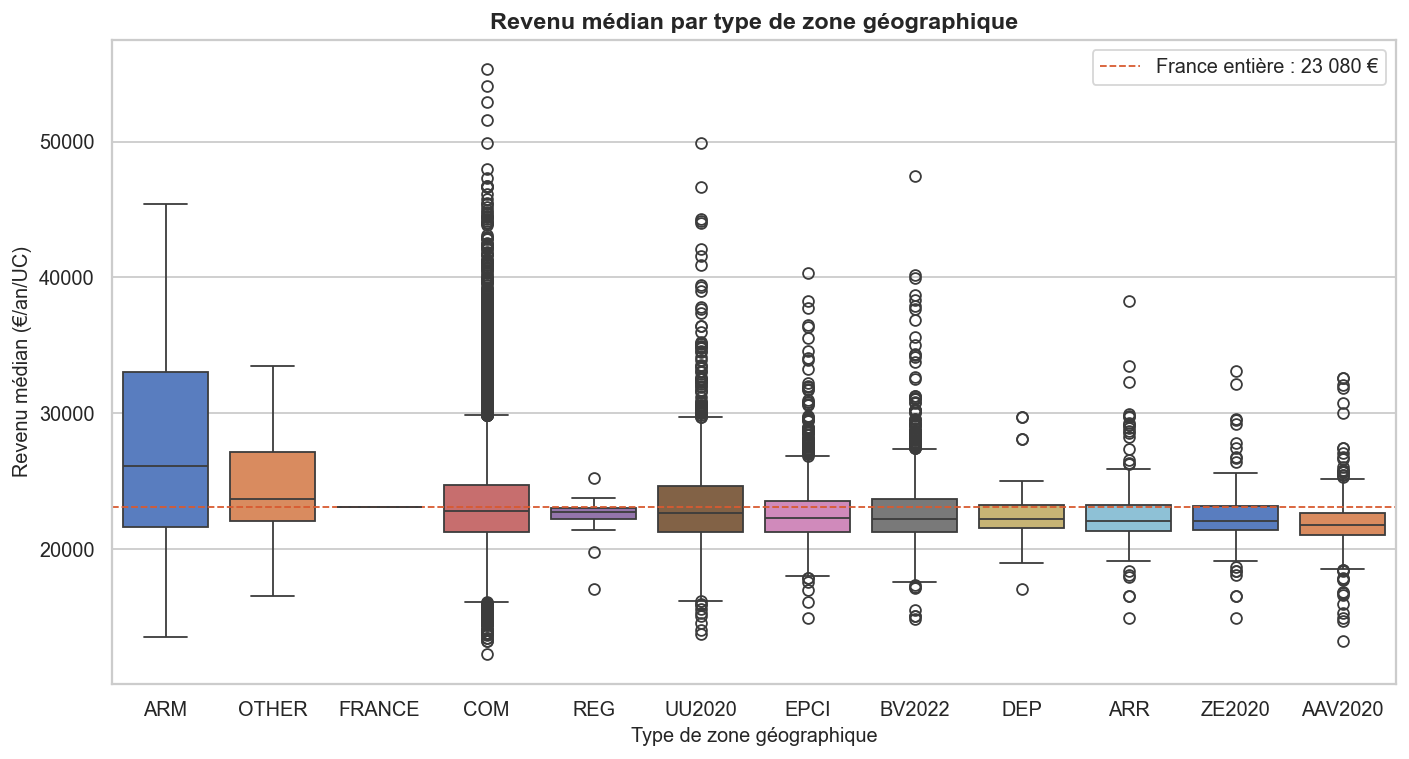

In [16]:
# Comparaison MED_SL par type de zone géographique
med_geo = df[(df['FILOSOFI_MEASURE'] == 'MED_SL') & df['OBS_VALUE'].notna()]

fig, ax = plt.subplots(figsize=(11, 6))
order = (med_geo.groupby('GEO_OBJECT')['OBS_VALUE'].median()
                .sort_values(ascending=False).index)
sns.boxplot(data=med_geo, x='GEO_OBJECT', y='OBS_VALUE',
            order=order, palette='muted', ax=ax)
ax.set_xlabel('Type de zone géographique')
ax.set_ylabel('Revenu médian (€/an/UC)')
ax.set_title('Revenu médian par type de zone géographique', fontweight='bold')
ax.axhline(23080, color='#D85A30', linestyle='--', linewidth=1, label='France entière : 23 080 €')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Inégalités de revenus

In [17]:
# Rapport interdécile D9/D1
ir = df_wide['IR_D9_D1_SL'].dropna()
print(f'Communes avec IR D9/D1 : {len(ir):,}')
print(f'Rapport moyen : {ir.mean():.2f}  —  Médiane : {ir.median():.2f}')
print(f'Min : {ir.min():.2f}  —  Max : {ir.max():.2f}')


Communes avec IR D9/D1 : 5,302
Rapport moyen : 2.95  —  Médiane : 2.80
Min : 2.00  —  Max : 11.20


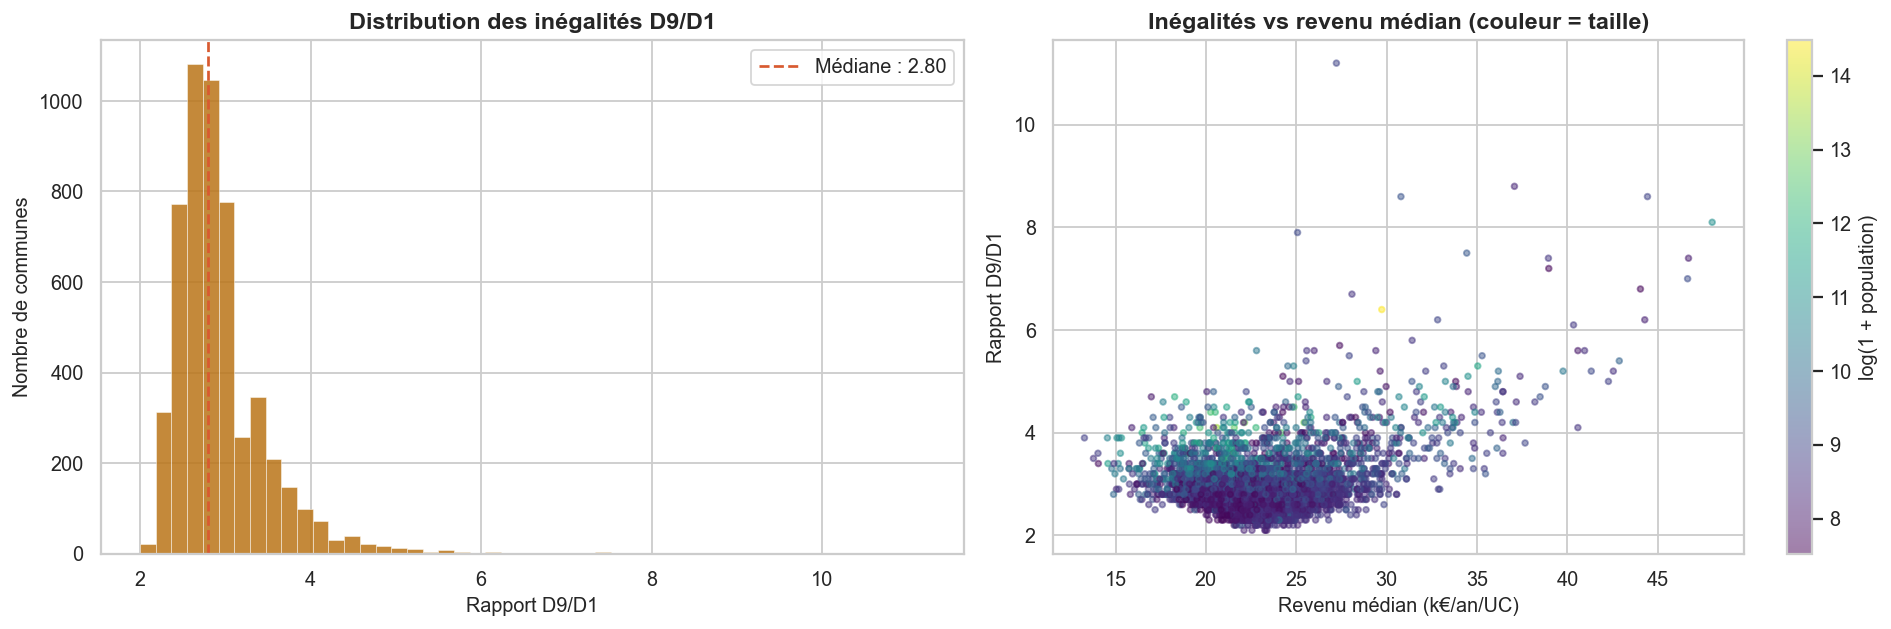

FILOSOFI_MEASURE,MED_SL,IR_D9_D1_SL,PR_MD60
FILOSOFI_MEASURE,,,
MED_SL,1.000,0.346,-0.738
IR_D9_D1_SL,0.346,1.000,0.263
PR_MD60,-0.738,0.263,1.000


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histo IR
axes[0].hist(ir, bins=50, color='#BA7517', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].axvline(ir.median(), color='#D85A30', linestyle='--', linewidth=1.5, label=f'Médiane : {ir.median():.2f}')
axes[0].set_xlabel('Rapport D9/D1')
axes[0].set_ylabel('Nombre de communes')
axes[0].set_title('Distribution des inégalités D9/D1', fontweight='bold')
axes[0].legend()

# Scatter MED_SL vs IR
sub = df_wide[['MED_SL','IR_D9_D1_SL','PR_MD60','NUM_PER']].dropna()
sc = axes[1].scatter(sub['MED_SL'] / 1000, sub['IR_D9_D1_SL'],
                     c=np.log1p(sub['NUM_PER']), cmap='viridis',
                     s=10, alpha=0.5)
cbar = fig.colorbar(sc, ax=axes[1])
cbar.set_label('log(1 + population)')
axes[1].set_xlabel('Revenu médian (k€/an/UC)')
axes[1].set_ylabel('Rapport D9/D1')
axes[1].set_title('Inégalités vs revenu médian (couleur = taille)', fontweight='bold')

plt.tight_layout()
plt.show()

corr = sub[['MED_SL','IR_D9_D1_SL','PR_MD60']].corr()
display(corr.style.format('{:.3f}').background_gradient(cmap='RdYlGn', vmin=-1, vmax=1))


## 8. Taux de pauvreté (PR_MD60)

In [19]:
pov = df_wide['PR_MD60'].dropna()
print(f'Communes avec PR_MD60 : {len(pov):,}')
print(f'Taux moyen    : {pov.mean():.1f} %')
print(f'Taux médian   : {pov.median():.1f} %')
print(f'Min : {pov.min():.1f} %  —  Max : {pov.max():.1f} %')
print(f'Communes > 25 % pauvreté : {(pov > 25).sum()} ({(pov > 25).mean()*100:.1f} %)')


Communes avec PR_MD60 : 4,354
Taux moyen    : 13.9 %
Taux médian   : 12.0 %
Min : 5.0 %  —  Max : 54.0 %
Communes > 25 % pauvreté : 291 (6.7 %)


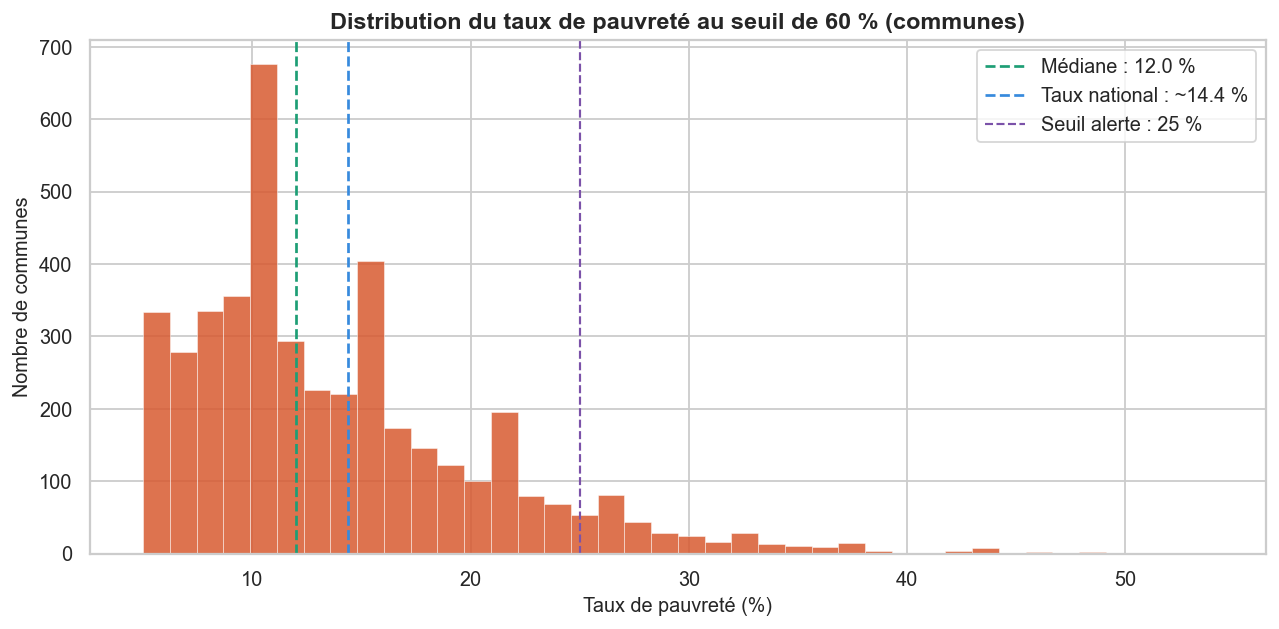

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pov, bins=40, color='#D85A30', alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(pov.median(), color='#1D9E75', linestyle='--', linewidth=1.5, label=f'Médiane : {pov.median():.1f} %')
ax.axvline(14.4, color='#378ADD', linestyle='--', linewidth=1.5, label='Taux national : ~14.4 %')
ax.axvline(25, color='#7B52A9', linestyle='--', linewidth=1.2, label='Seuil alerte : 25 %')
ax.set_xlabel('Taux de pauvreté (%)')
ax.set_ylabel('Nombre de communes')
ax.set_title('Distribution du taux de pauvreté au seuil de 60 % (communes)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


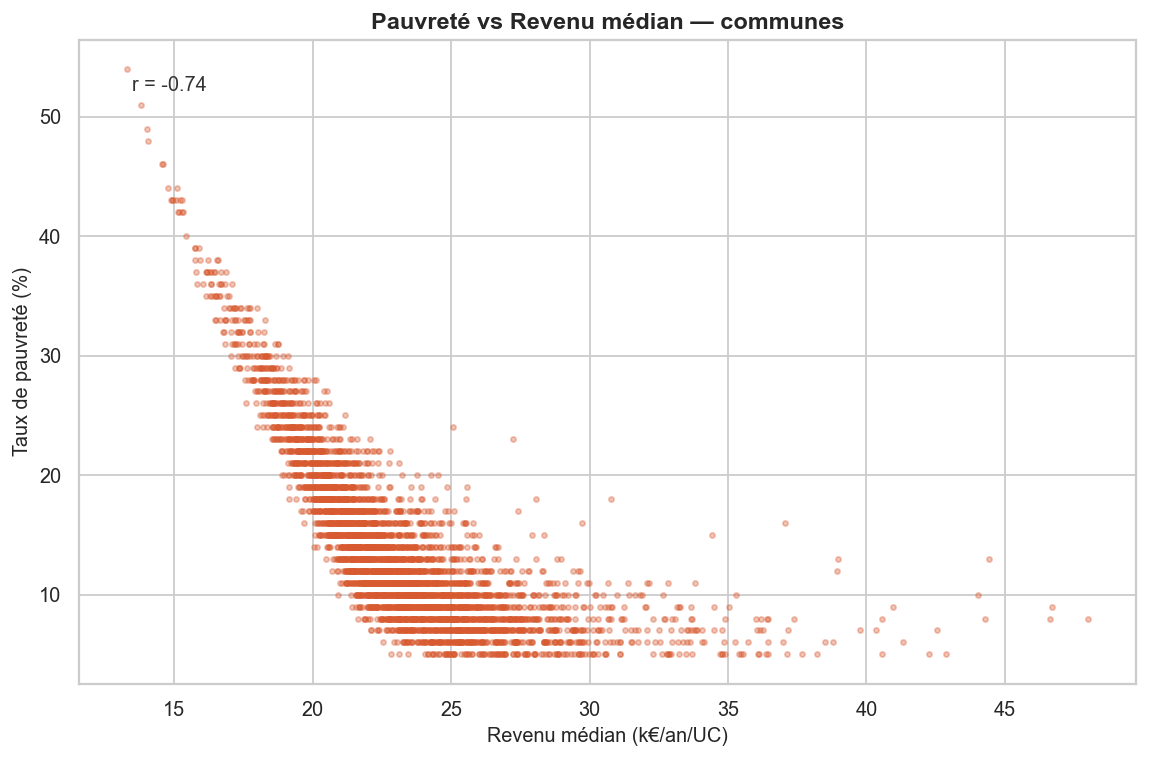

In [21]:
# Scatter pauvreté vs revenu médian
sub2 = df_wide[['MED_SL','PR_MD60']].dropna()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sub2['MED_SL'] / 1000, sub2['PR_MD60'],
           alpha=0.35, s=8, color='#D85A30')
ax.set_xlabel('Revenu médian (k€/an/UC)')
ax.set_ylabel('Taux de pauvreté (%)')
ax.set_title('Pauvreté vs Revenu médian — communes', fontweight='bold')

corr_val = sub2.corr().loc['MED_SL','PR_MD60']
ax.text(0.05, 0.92, f'r = {corr_val:.2f}', transform=ax.transAxes,
        fontsize=11, color='#333')
plt.tight_layout()
plt.show()


## 9. Structure du revenu disponible

C:\Users\ervin\AppData\Local\Temp\ipykernel_42364\1161190578.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(sub_pos.values, labels=[labels_parts[c] for c in sub_pos.columns],


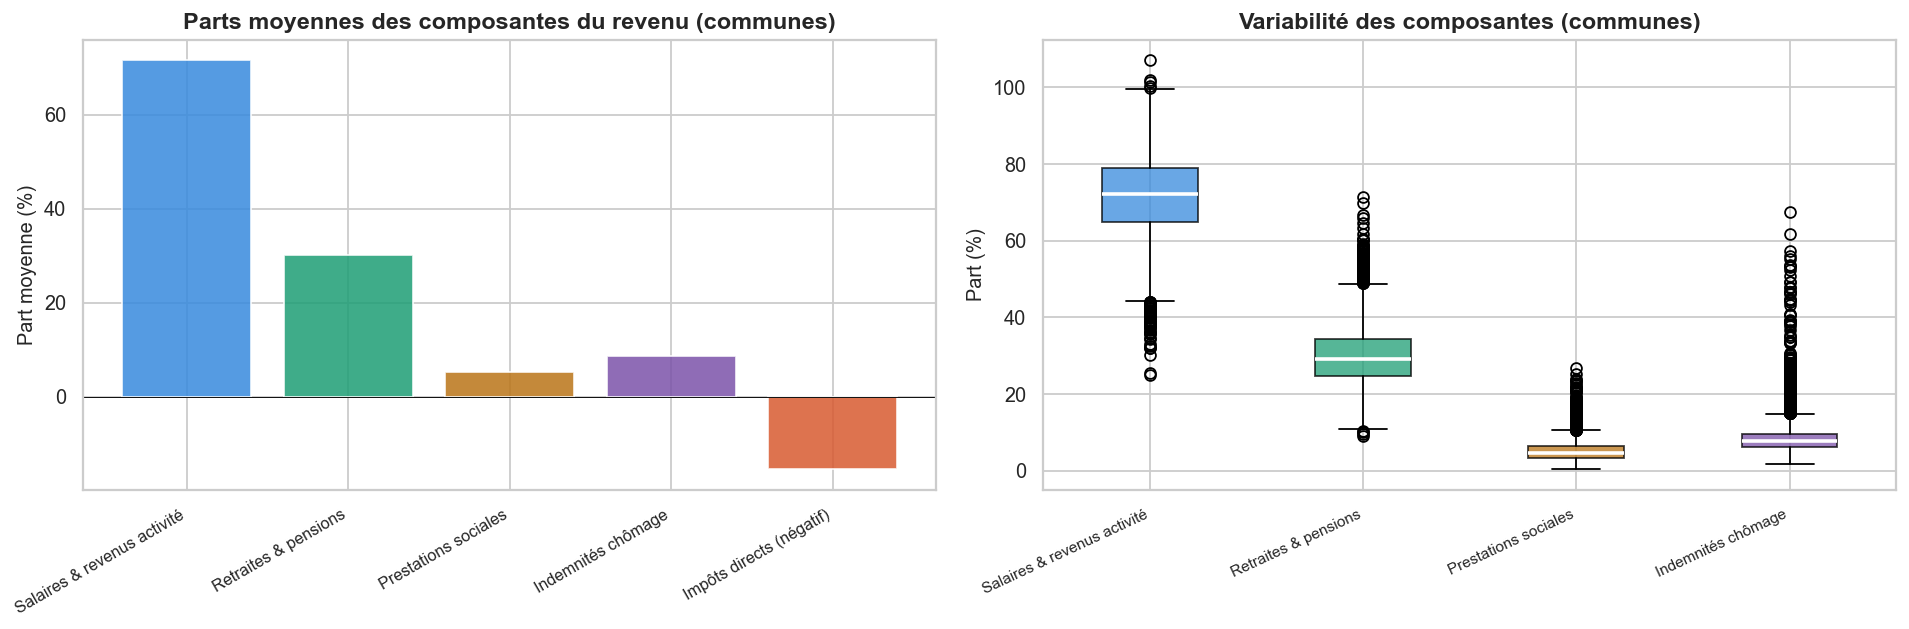

In [22]:
parts = ['S_EI_DI','S_RET_PEN_DI','S_SOC_BEN_DI','S_INC_ASS_DI','S_DIR_TAX_DI']
labels_parts = {
    'S_EI_DI'      : 'Salaires & revenus activité',
    'S_RET_PEN_DI' : 'Retraites & pensions',
    'S_SOC_BEN_DI' : 'Prestations sociales',
    'S_INC_ASS_DI' : 'Indemnités chômage',
    'S_DIR_TAX_DI' : 'Impôts directs (négatif)',
}

sub_parts = df_wide[parts].dropna()
means = sub_parts.mean().rename(labels_parts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart des parts moyennes
colors_parts = ['#378ADD','#1D9E75','#BA7517','#7B52A9','#D85A30']
axes[0].bar(range(len(means)), means.values, color=colors_parts, alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(means)))
axes[0].set_xticklabels(means.index, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Part moyenne (%)')
axes[0].set_title('Parts moyennes des composantes du revenu (communes)', fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.5)

# Box plots
sub_pos = df_wide[['S_EI_DI','S_RET_PEN_DI','S_SOC_BEN_DI','S_INC_ASS_DI']].dropna()
bp = axes[1].boxplot(sub_pos.values, labels=[labels_parts[c] for c in sub_pos.columns],
                     patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors_parts[:4]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_ylabel('Part (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right', fontsize=8.5)
axes[1].set_title('Variabilité des composantes (communes)', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Taille des communes (NUM_HH, NUM_PER)

In [23]:
hh = df_wide['NUM_HH'].dropna()
per = df_wide['NUM_PER'].dropna()

print(f'Communes avec NUM_HH : {len(hh):,}')
print(f'  Médiane : {hh.median():,.0f} ménages  —  Max : {hh.max():,.0f}')
print()
print(f'Communes avec NUM_PER : {len(per):,}')
print(f'  Médiane : {per.median():,.0f} pers.  —  Max : {per.max():,.0f}')


Communes avec NUM_HH : 31,212
  Médiane : 227 ménages  —  Max : 1,007,247

Communes avec NUM_PER : 31,212
  Médiane : 526 pers.  —  Max : 1,958,437


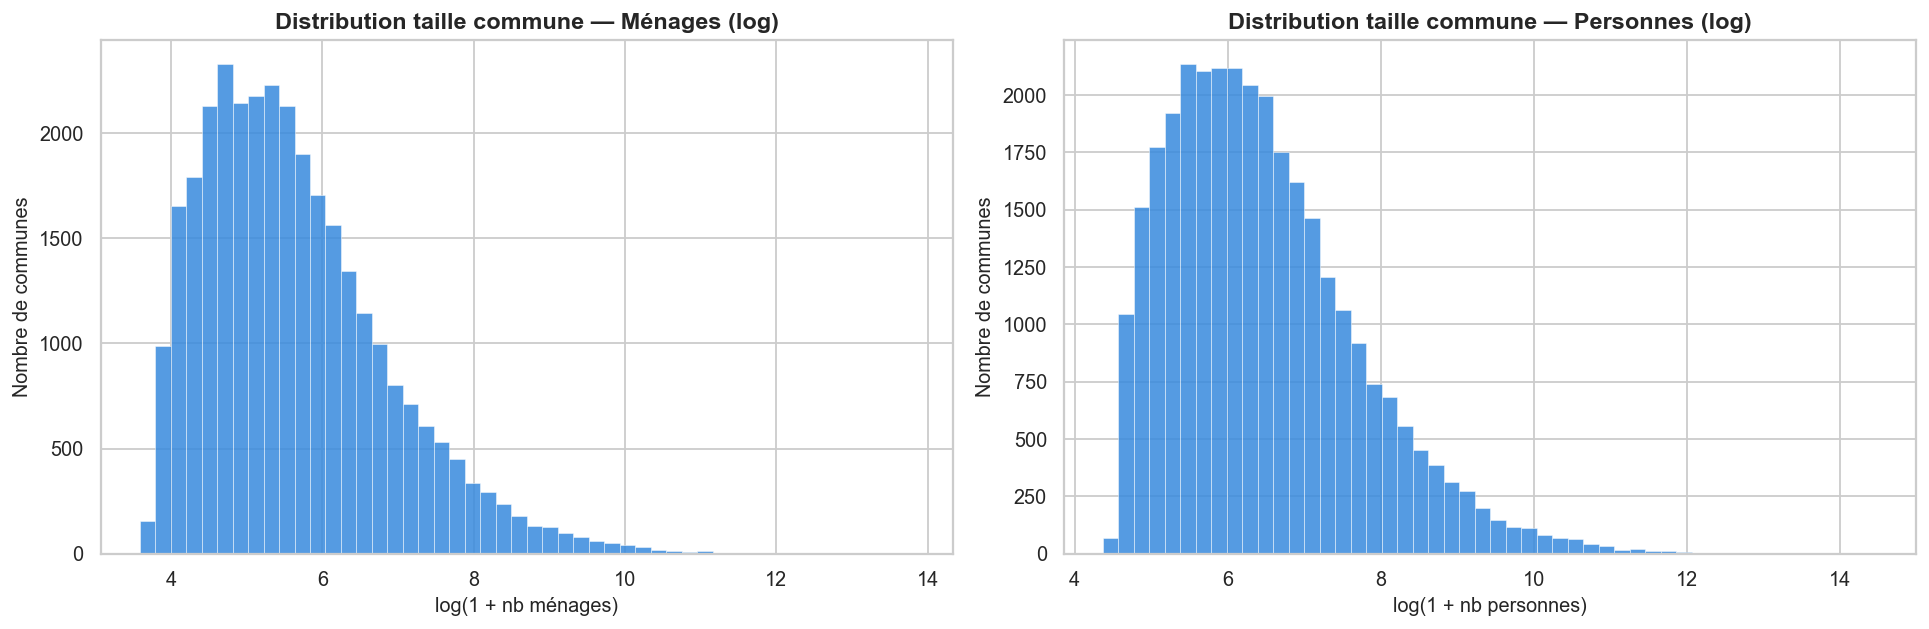

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (col, label) in zip(axes, [('NUM_HH','Ménages'), ('NUM_PER','Personnes')]):
    data = np.log1p(df_wide[col].dropna())
    ax.hist(data, bins=50, color='#378ADD', alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_xlabel(f'log(1 + nb {label.lower()})')
    ax.set_ylabel('Nombre de communes')
    ax.set_title(f'Distribution taille commune — {label} (log)', fontweight='bold')

plt.tight_layout()
plt.show()


## 11. Matrice de corrélation

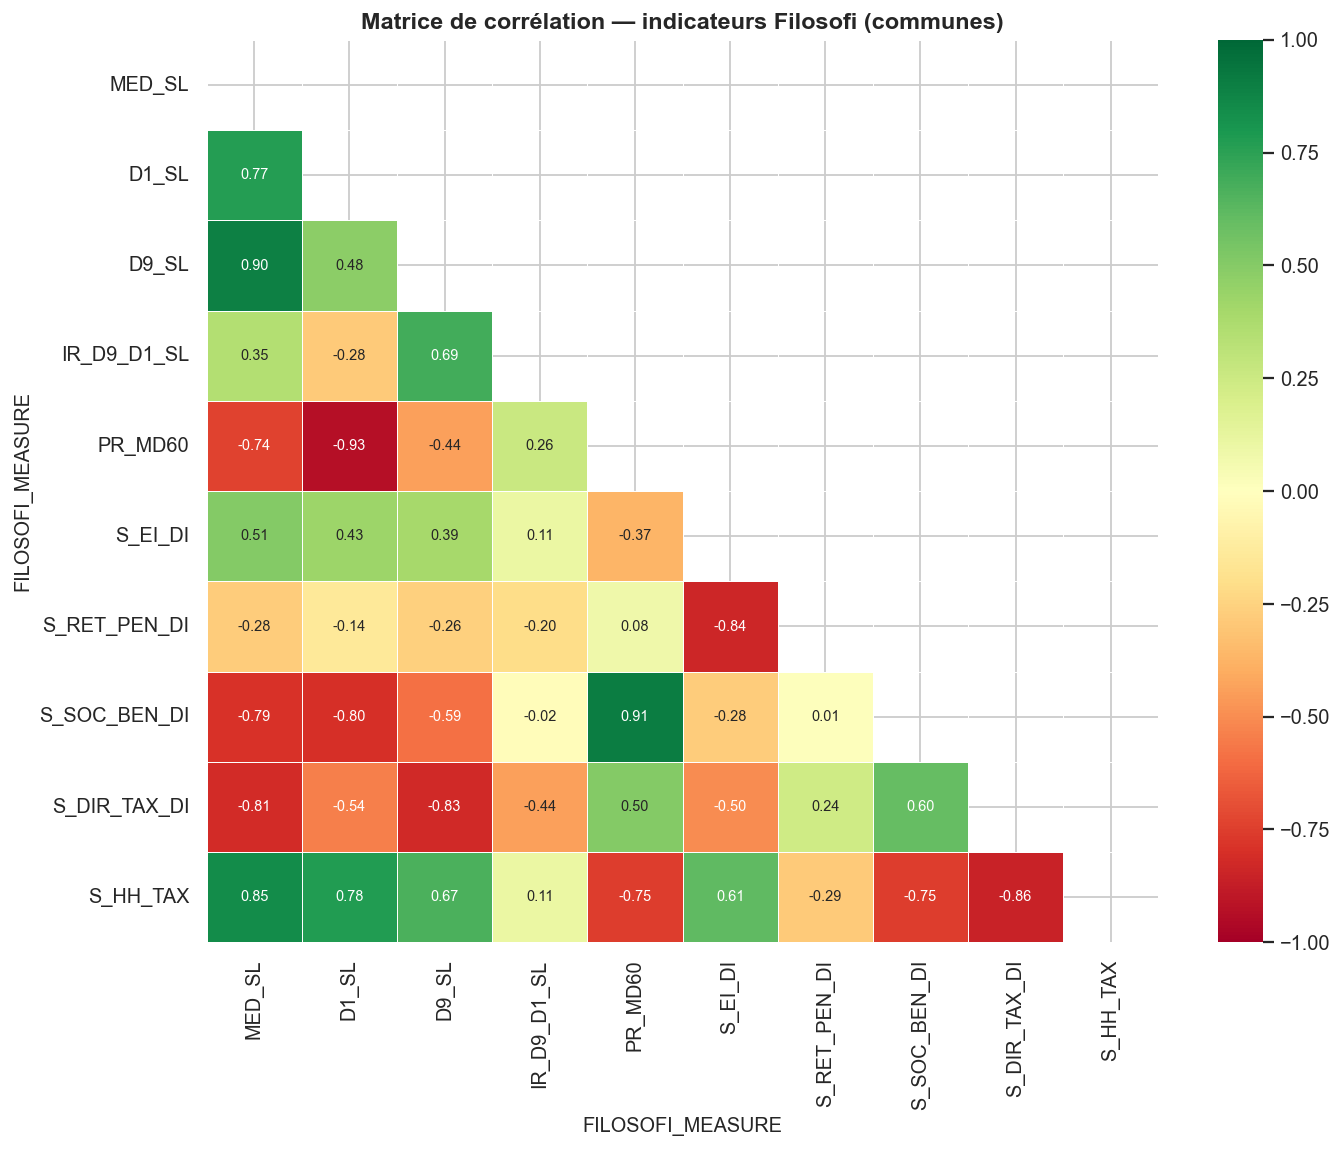

In [25]:
cols_corr = ['MED_SL','D1_SL','D9_SL','IR_D9_D1_SL','PR_MD60',
            'S_EI_DI','S_RET_PEN_DI','S_SOC_BEN_DI','S_DIR_TAX_DI','S_HH_TAX']

corr_mat = df_wide[cols_corr].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation — indicateurs Filosofi (communes)', fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Table silver — prête pour le pipeline

In [26]:
cols_silver = ['MED_SL','D1_SL','D9_SL','IR_D9_D1_SL','PR_MD60',
              'NUM_HH','NUM_PER','NUM_CU',
              'S_EI_DI','S_RET_PEN_DI','S_SOC_BEN_DI',
              'S_HH_TAX','S_DIR_TAX_DI']

df_silver = df_wide[cols_silver].reset_index().rename(columns={
    'GEO'          : 'code_commune',
    'MED_SL'       : 'revenu_median_uc',
    'D1_SL'        : 'decile1_revenu',
    'D9_SL'        : 'decile9_revenu',
    'IR_D9_D1_SL'  : 'rapport_d9_d1',
    'PR_MD60'      : 'taux_pauvrete_60pct',
    'NUM_HH'       : 'nb_menages',
    'NUM_PER'      : 'nb_personnes',
    'NUM_CU'       : 'nb_uc',
    'S_EI_DI'      : 'part_salaires_pct',
    'S_RET_PEN_DI' : 'part_retraites_pct',
    'S_SOC_BEN_DI' : 'part_prestations_soc_pct',
    'S_HH_TAX'     : 'part_menages_imposes_pct',
    'S_DIR_TAX_DI' : 'part_impots_directs_pct',
})

print(f'Table silver : {df_silver.shape[0]:,} communes × {df_silver.shape[1]} colonnes')
print(f'Taux de remplissage MED_SL : {df_silver["revenu_median_uc"].notna().mean()*100:.1f} %')
display(df_silver.head(5))


Table silver : 31,212 communes × 14 colonnes
Taux de remplissage MED_SL : 100.0 %


FILOSOFI_MEASURE,code_commune,revenu_median_uc,decile1_revenu,decile9_revenu,rapport_d9_d1,taux_pauvrete_60pct,nb_menages,nb_personnes,nb_uc,part_salaires_pct,part_retraites_pct,part_prestations_soc_pct,part_menages_imposes_pct,part_impots_directs_pct
0,01001,25820.0,NaN,NaN,NaN,NaN,346.0,895.0,590.8,NaN,NaN,NaN,NaN,NaN
1,01002,24480.0,NaN,NaN,NaN,NaN,115.0,266.0,181.0,NaN,NaN,NaN,NaN,NaN
2,01004,21660.0,11890.0,36450.0,3.1,17.0,6855.0,15092.0,10398.2,72.3,25.3,7.0,50.0,-14.8
3,01005,24610.0,15560.0,40580.0,2.6,NaN,800.0,2028.0,1329.7,81.5,21.4,3.4,61.0,-16.3
4,01006,24210.0,NaN,NaN,NaN,NaN,51.0,107.0,76.6,NaN,NaN,NaN,NaN,NaN


## 13. Résumé EDA

In [27]:
print("=== RÉSUMÉ EDA — DS_FILOSOFI_CC_data ===\n")
print(f"Lignes totales              : {len(df):,}")
print(f"Format                      : long (SDMX) — 1 ligne = 1 mesure × 1 zone × 1 année")
print(f"Année couverte              : 2021")
print(f"Types de zones géographiques: {df['GEO_OBJECT'].nunique()}")
print(f"Zones uniques (GEO)         : {df['GEO'].nunique():,}")
print(f"Indicateurs                 : {df['FILOSOFI_MEASURE'].nunique()}")
print()
print("── Communes (COM) ──")
print(f"  Communes totales dans le fichier : {df[df['GEO_OBJECT']=='COM']['GEO'].nunique():,}")
print(f"  Communes avec MED_SL renseigné   : {df_wide['MED_SL'].notna().sum():,}")
print(f"  Revenu médian médian             : {df_wide['MED_SL'].median():,.0f} €/an/UC")
print(f"  Rapport D9/D1 médian             : {df_wide['IR_D9_D1_SL'].median():.2f}")
print(f"  Taux pauvreté médian             : {df_wide['PR_MD60'].median():.1f} %")
print()
print("── Qualité données ──")
print(f"  NaN structurels (CONF_STATUS=C)  : données sous seuil de diffusion INSEE")
print(f"  Communes avec revenu médian       : ~90 % (NUM_HH/NUM_PER/MED_SL)")
print(f"  Communes avec indicateurs d inégalité : ~15 % (D1, D9, IR, PR_MD60)")


=== RÉSUMÉ EDA — DS_FILOSOFI_CC_data ===

Lignes totales              : 833,400
Format                      : long (SDMX) — 1 ligne = 1 mesure × 1 zone × 1 année
Année couverte              : 2021
Types de zones géographiques: 12
Zones uniques (GEO)         : 37,812
Indicateurs                 : 20

── Communes (COM) ──
  Communes totales dans le fichier : 34,804
  Communes avec MED_SL renseigné   : 31,212
  Revenu médian médian             : 22,810 €/an/UC
  Rapport D9/D1 médian             : 2.80
  Taux pauvreté médian             : 12.0 %

── Qualité données ──
  NaN structurels (CONF_STATUS=C)  : données sous seuil de diffusion INSEE
  Communes avec revenu médian       : ~90 % (NUM_HH/NUM_PER/MED_SL)
  Communes avec indicateurs d inégalité : ~15 % (D1, D9, IR, PR_MD60)
